# Overview

First dip into this dataset! Will do some EDAs to understand the nature of the dataset and variables. I'm using Pandas Profiling to generate quick standard EDA before deep-diving

Reference notebooks:
* https://www.kaggle.com/artgor/eda-and-models: Join trx and cust from the start. Histograms of variables (except V variables). LGB pred
* https://www.kaggle.com/jazivxt/safe-box: Uses the1owl package for autoML
* https://www.kaggle.com/jesucristo/fraud-complete-eda: time series analysis

In [1]:
!pip install pandas-profiling

In [2]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler
from sklearn.svm import NuSVR, SVR
from sklearn.metrics import mean_absolute_error
pd.options.display.precision = 15

import lightgbm as lgb
import xgboost as xgb
import time
import datetime
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedKFold, GroupKFold, GridSearchCV, train_test_split, TimeSeriesSplit
from sklearn import metrics
from sklearn import linear_model
import gc
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import eli5
import shap
from IPython.display import HTML
import json
# import altair as alt

import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

# alt.renderers.enable('notebook')


Using TensorFlow backend.


In [3]:
import pandas_profiling
import plotly.graph_objs as go
# import plotly.plotly as py
import plotly.offline as pyo
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly_express as px
init_notebook_mode(connected=True)
from matplotlib import cm
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import plotly_express as px

# Loading data

In [4]:
folder_path = '../input/'
train_identity = pd.read_csv(f'{folder_path}train_identity.csv')
train_transaction = pd.read_csv(f'{folder_path}train_transaction.csv')
# test_identity = pd.read_csv(f'{folder_path}test_identity.csv')
# test_transaction = pd.read_csv(f'{folder_path}test_transaction.csv')
sub = pd.read_csv(f'{folder_path}sample_submission.csv')
# let's combine the data and work with the whole dataset
# I will save this for later
# train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
# test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

In [5]:
print(f'Train Transaction dataset has {train_transaction.shape[0]} rows and {train_transaction.shape[1]} columns.')

Train Transaction dataset has 590540 rows and 394 columns.


In [6]:
# print(f'Train dataset has {train.shape[0]} rows and {train.shape[1]} columns.')
# print(f'Test dataset has {test.shape[0]} rows and {test.shape[1]} columns.')

# EDA - Train_Transaction

Let's quickly check the transaction table

In [7]:
train_transaction = train_transaction.sample(n=100000)
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
29605,3016605,0,753090,984.190000000000055,W,3178,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
290051,3277051,0,7149764,117.000000000000000,W,7861,494.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395516,3382516,0,9936250,129.949999999999989,W,2455,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7203,2994203,0,236361,77.000000000000000,W,12544,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438662,3425662,0,11118986,77.000000000000000,W,2278,543.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
trx_colnames = train_transaction.columns
for i in range(len(trx_colnames)):
    print(i, ': ',trx_colnames[i])

0 :  TransactionID
1 :  isFraud
2 :  TransactionDT
3 :  TransactionAmt
4 :  ProductCD
5 :  card1
6 :  card2
7 :  card3
8 :  card4
9 :  card5
10 :  card6
11 :  addr1
12 :  addr2
13 :  dist1
14 :  dist2
15 :  P_emaildomain
16 :  R_emaildomain
17 :  C1
18 :  C2
19 :  C3
20 :  C4
21 :  C5
22 :  C6
23 :  C7
24 :  C8
25 :  C9
26 :  C10
27 :  C11
28 :  C12
29 :  C13
30 :  C14
31 :  D1
32 :  D2
33 :  D3
34 :  D4
35 :  D5
36 :  D6
37 :  D7
38 :  D8
39 :  D9
40 :  D10
41 :  D11
42 :  D12
43 :  D13
44 :  D14
45 :  D15
46 :  M1
47 :  M2
48 :  M3
49 :  M4
50 :  M5
51 :  M6
52 :  M7
53 :  M8
54 :  M9
55 :  V1
56 :  V2
57 :  V3
58 :  V4
59 :  V5
60 :  V6
61 :  V7
62 :  V8
63 :  V9
64 :  V10
65 :  V11
66 :  V12
67 :  V13
68 :  V14
69 :  V15
70 :  V16
71 :  V17
72 :  V18
73 :  V19
74 :  V20
75 :  V21
76 :  V22
77 :  V23
78 :  V24
79 :  V25
80 :  V26
81 :  V27
82 :  V28
83 :  V29
84 :  V30
85 :  V31
86 :  V32
87 :  V33
88 :  V34
89 :  V35
90 :  V36
91 :  V37
92 :  V38
93 :  V39
94 :  V40
95 :  V41
96 : 

In [9]:
trx_colnames_main = trx_colnames[1:17]
trx_colnames_CDM = trx_colnames[17:55]
trx_colnames_V = trx_colnames[55:]

Check out pandas profiling report below. This library generates a summary of dataset, including number of null, distribution of values, correlation, etc. It also suggests which variables should be dropped due to high correlation. I am commenting it out because it consumes tons of memory, so I'm running it offline one-time.

In [10]:
# profiler1 = train_transaction[trx_colnames_main].profile_report()
# profiler1

In [11]:
# profiler2 = train_transaction[trx_colnames_CDM].profile_report()
# profiler2

# EDA - Transaction - Key Takeaways from Pandas Profiler
* C: The variables here are highly correlated
* D: A lot of zeros or missing to deal with
* M: Half is missing! 
* A lot of them are highlyg skewed, or having a very long tail to the right


# Util to check memory consumption

This is a useful function to check the memory consumption size of our python objects:

In [12]:
import sys

# These are the usual ipython objects, including this one you are creating
ipython_vars = ['In', 'Out', 'exit', 'quit', 'get_ipython', 'ipython_vars']

# Get a sorted list of the objects and their sizes
sorted([(x, sys.getsizeof(globals().get(x))) for x in dir() if not x.startswith('_') and x not in sys.modules and x not in ipython_vars], key=lambda x: x[1], reverse=True)

[('train_transaction', 377770283),
 ('train_identity', 169802794),
 ('sub', 8107208),
 ('trx_colnames', 34189),
 ('trx_colnames_V', 20595),
 ('trx_colnames_CDM', 2277),
 ('CatBoostRegressor', 1056),
 ('GridSearchCV', 1056),
 ('GroupKFold', 1056),
 ('HTML', 1056),
 ('KFold', 1056),
 ('KMeans', 1056),
 ('LabelEncoder', 1056),
 ('NuSVR', 1056),
 ('PCA', 1056),
 ('RepeatedKFold', 1056),
 ('SVR', 1056),
 ('StandardScaler', 1056),
 ('StratifiedKFold', 1056),
 ('TimeSeriesSplit', 1056),
 ('trx_colnames_main', 1055),
 ('download_plotlyjs', 136),
 ('init_notebook_mode', 136),
 ('iplot', 136),
 ('mean_absolute_error', 136),
 ('plot', 136),
 ('tqdm_notebook', 136),
 ('train_test_split', 136),
 ('cm', 80),
 ('go', 80),
 ('lgb', 80),
 ('linear_model', 80),
 ('metrics', 80),
 ('np', 80),
 ('nx', 80),
 ('pd', 80),
 ('plt', 80),
 ('px', 80),
 ('pyo', 80),
 ('sns', 80),
 ('tools', 80),
 ('xgb', 80),
 ('folder_path', 58),
 ('i', 28)]

# Variable: Cs

In [13]:
trx_colnames_C = [c for c in trx_colnames if c.startswith("C") ]
trx_colnames_C

['C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14']

Text(0.5, 0.98, 'Distribution of C variables - C, log(C), cumulative log(C)')

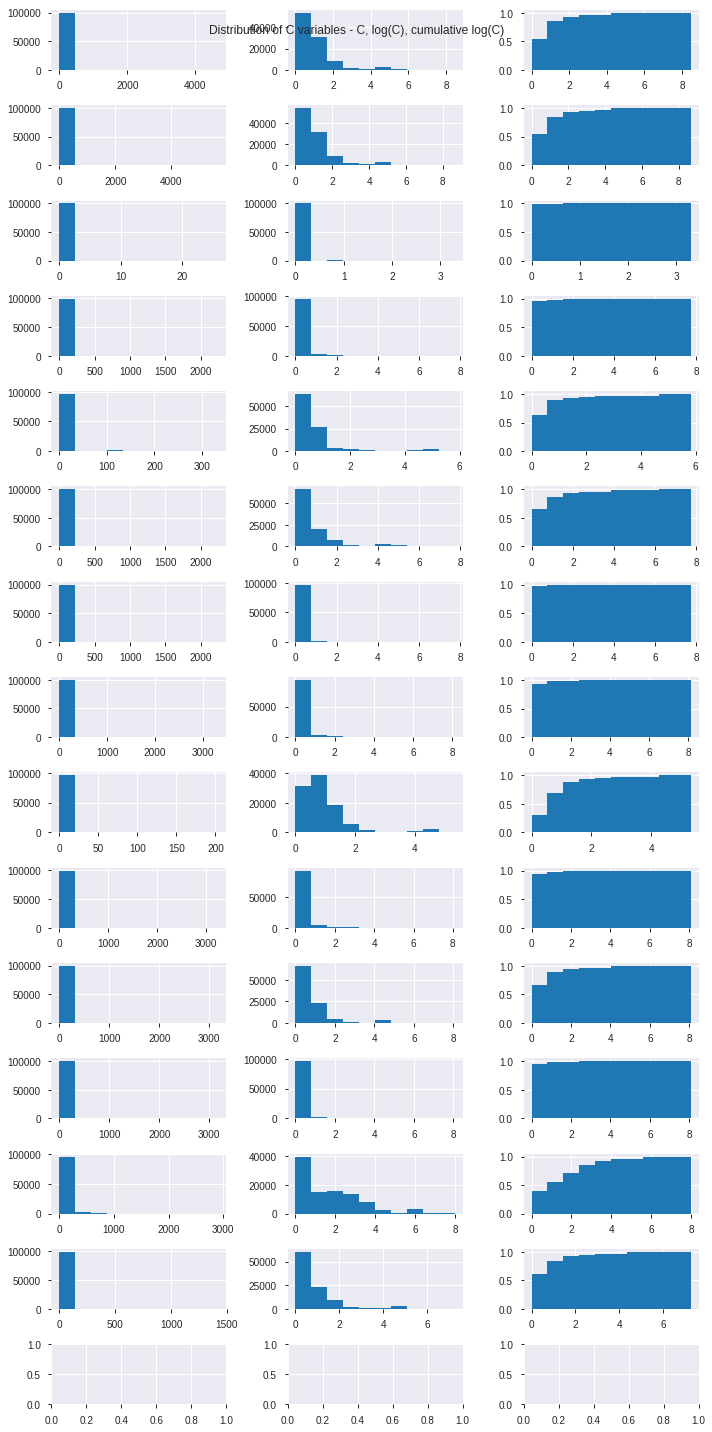

In [14]:
trxC = train_transaction[trx_colnames_C]
trxClog = np.log1p(trxC)
fig, ax = plt.subplots(15,3,figsize=(10,20))
for i,c in enumerate(trxC.columns):
    trxC[c].hist(ax=ax[i,0])
    trxClog[c].hist(ax=ax[i,1])
    trxClog[c].hist(ax=ax[i,2],cumulative=True,density=True)
plt.tight_layout()
plt.suptitle('Distribution of C variables - C, log(C), cumulative log(C)')

In [15]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [16]:
X = trxClog
pca = PCA(n_components=len(trx_colnames_C)).fit(X)
#Plotting the Cumulative Summation of the Explained Variance
expvar=np.cumsum(pca.explained_variance_ratio_)
data = [go.Scatter(y=expvar)]
layout = {'title': 'Review PCA Explained Variance to determine number of components'}
iplot({'data':data,'layout':layout})

In [17]:
pca = PCA(n_components=4)
XPCA = pca.fit_transform(X)
Nc = range(1,10)
kmeans = [KMeans(i) for i in Nc]
score = [kmeans[i].fit(XPCA).score(XPCA) for i in range(len(kmeans))]
data = [go.Scatter(y=score,x=list(Nc))]
layout = {'title':'Review Elbow Curve to determine number of clusters for KMeans'}
iplot({'data':data,'layout':layout})

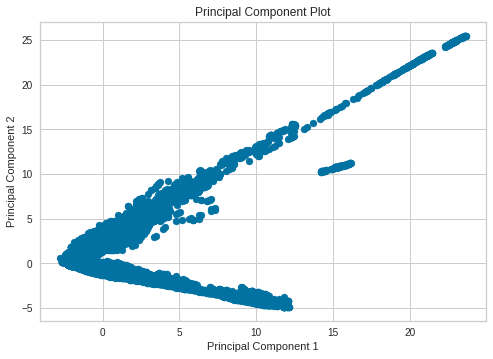

In [18]:
from yellowbrick.features.pca import PCADecomposition
visualizer = PCADecomposition(scale=True)
visualizer.fit_transform(trxClog)
visualizer.poof()

# Variable: Vs

In [19]:
trx_colnames_V = [c for c in trx_colnames if c.startswith("V") ]
trx_colnames_V

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V86',
 'V87',
 'V88',
 'V89',
 'V90',
 'V91',
 'V92',
 'V93',
 'V94',
 'V95',
 'V96',
 'V97',
 'V98',
 'V99',
 'V100',
 'V101',
 'V102',
 'V103',
 'V104',
 'V105',
 'V106',
 'V107',
 'V108',
 'V109',
 'V110',
 'V111',
 'V112',
 'V113',
 'V114',
 'V115',
 'V116',
 'V117',
 'V118',
 'V119',
 'V120',
 'V121',
 'V122',
 'V123',
 'V124',
 'V125',
 'V126',
 'V127',
 'V128',
 'V129',
 'V130',
 'V131',
 'V132',
 'V133',
 'V134',
 'V135',
 'V136',
 'V137',
 'V138',
 'V139',
 'V140',
 'V141',
 'V142',
 'V143',
 'V144',
 'V145',
 'V146',
 'V147',
 'V148',
 'V149',
 'V150',
 'V151',
 'V152',
 'V153',
 'V154',
 'V155',
 'V156',
 'V157',
 'V158',
 'V159',
 'V160',
 'V161',
 'V162',
 'V163',
 'V164',
 'V165',
 'V166',
 'V167',
 'V168',
 'V169',
 'V170',
 'V171',
 'V172',
 'V173',
 'V174',
 'V175',
 'V176',
 'V177',
 'V178',
 'V179',
 'V180',
 'V181',
 'V182',
 'V183',
 'V184',
 'V185',
 'V186',
 'V187',
 'V188',
 'V189',
 'V190',
 'V191',
 'V192',
 'V193',
 'V194',
 'V195',
 'V196',
 'V197',
 'V198',
 'V199',
 'V200',
 'V201',
 'V202',
 'V203',
 'V204',
 'V205',
 'V206',
 'V207',
 'V208',
 'V209',
 'V210',
 'V211',
 'V212',
 'V213',
 'V214',
 'V215',
 'V216',
 'V217',
 'V218',
 'V219',
 'V220',
 'V221',
 'V222',
 'V223',
 'V224',
 'V225',
 'V226',
 'V227',
 'V228',
 'V229',
 'V230',
 'V231',
 'V232',
 'V233',
 'V234',
 'V235',
 'V236',
 'V237',
 'V238',
 'V239',
 'V240',
 'V241',
 'V242',
 'V243',
 'V244',
 'V245',
 'V246',
 'V247',
 'V248',
 'V249',
 'V250',
 'V251',
 'V252',
 'V253',
 'V254',
 'V255',
 'V256',
 'V257',
 'V258',
 'V259',
 'V260',
 'V261',
 'V262',
 'V263',
 'V264',
 'V265',
 'V266',
 'V267',
 'V268',
 'V269',
 'V270',
 'V271',
 'V272',
 'V273',
 'V274',
 'V275',
 'V276',
 'V277',
 'V278',
 'V279',
 'V280',
 'V281',
 'V282',
 'V283',
 'V284',
 'V285',
 'V286',
 'V287',
 'V288',
 'V289',
 'V290',
 'V291',
 'V292',
 'V293',
 'V294',
 'V295',
 'V296',
 'V297',
 'V298',
 'V299',
 'V300',
 'V301',
 'V302',
 'V303',
 'V304',
 'V305',
 'V306',
 'V307',
 'V308',
 'V309',
 'V310',
 'V311',
 'V312',
 'V313',
 'V314',
 'V315',
 'V316',
 'V317',
 'V318',
 'V319',
 'V320',
 'V321',
 'V322',
 'V323',
 'V324',
 'V325',
 'V326',
 'V327',
 'V328',
 'V329',
 'V330',
 'V331',
 'V332',
 'V333',
 'V334',
 'V335',
 'V336',
 'V337',
 'V338',
 'V339']

Text(0.5, 0.98, 'Distribution of V variables - V, log(V), cumulative log(V)')

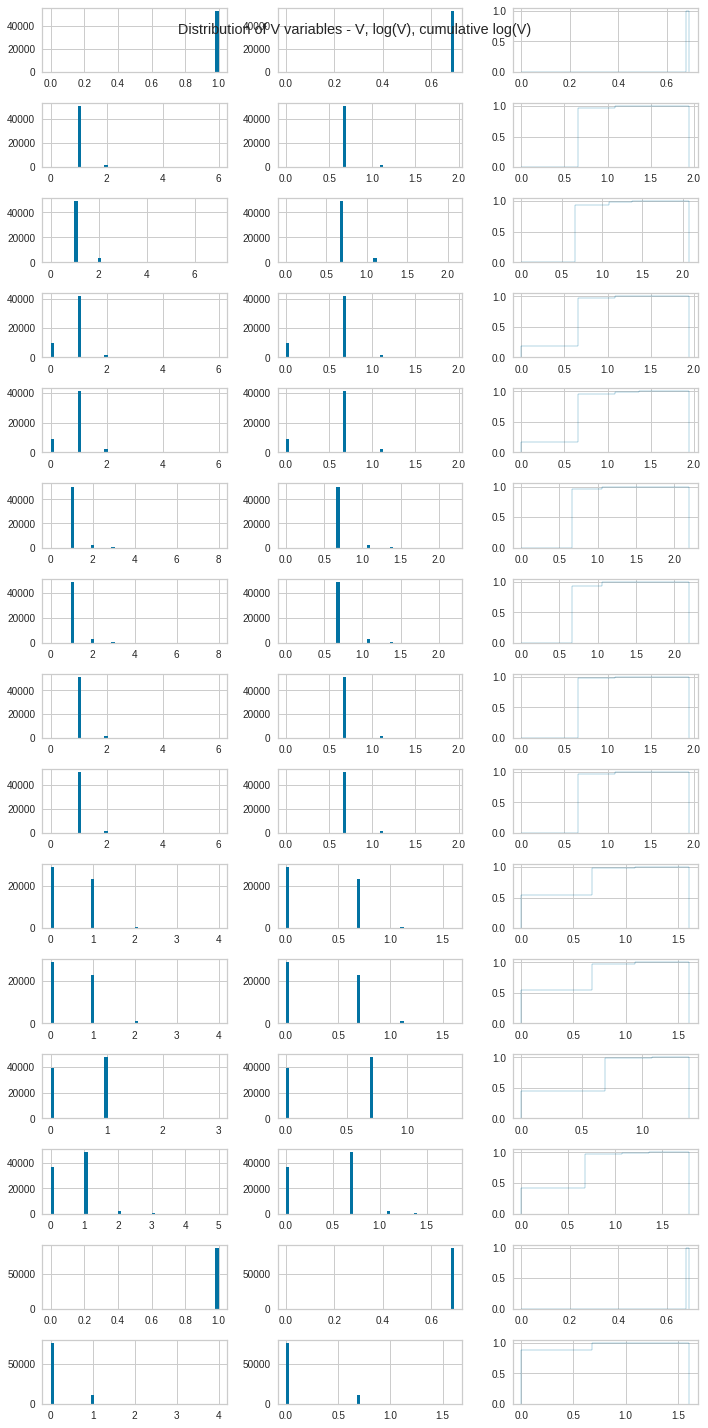

In [20]:
trxV = train_transaction[trx_colnames_V]
trxVlog = np.log1p(trxV)
fig, ax = plt.subplots(15,3,figsize=(10,20))
for i,c in enumerate(trxV.columns[:15]):
    trxV[c].hist(ax=ax[i,0],bins=50)
    trxVlog[c].hist(ax=ax[i,1],bins=50)
    trxVlog[c].hist(ax=ax[i,2],bins=50,cumulative=True,density=True,histtype='step')
plt.tight_layout()
plt.suptitle('Distribution of V variables - V, log(V), cumulative log(V)')

There is too much na. Need to strategize around na. May make more sense to convert the V into categorical, and then do embedding.

In [21]:
X = trxV.fillna(0)
pca = PCA(n_components=10).fit(X)
#Plotting the Cumulative Summation of the Explained Variance
expvar=np.cumsum(pca.explained_variance_ratio_)
data = [go.Scatter(y=expvar)]
layout = {'title': 'Review PCA Explained Variance to determine number of components'}
iplot({'data':data,'layout':layout})

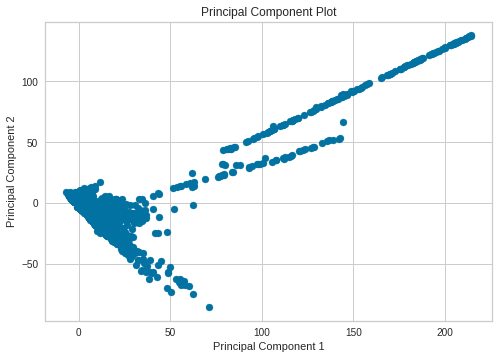

In [22]:
from yellowbrick.features.pca import PCADecomposition
visualizer = PCADecomposition(scale=True)
visualizer.fit_transform(trxV.fillna(0))
visualizer.poof()

We don't need to do log transformation

# Datetime analysis

Reference: 
* https://www.kaggle.com/fchmiel/day-and-time-powerful-predictive-feature
* https://www.kaggle.com/kevinbonnes/transactiondt-starting-at-2017-12-01

In [23]:
def make_day_feature(df, offset=0, tname='TransactionDT'):
    """
    Creates a day of the week feature, encoded as 0-6. 
    
    Parameters:
    -----------
    df : pd.DataFrame
        df to manipulate.
    offset : float (default=0)
        offset (in days) to shift the start/end of a day.
    tname : str
        Name of the time column in df.
    """
    # found a good offset is 0.58
    days = df[tname] / (3600*24)        
    encoded_days = np.floor(days-1+offset) % 7
    return encoded_days

def make_hour_feature(df, tname='TransactionDT'):
    """
    Creates an hour of the day feature, encoded as 0-23. 
    
    Parameters:
    -----------
    df : pd.DataFrame
        df to manipulate.
    tname : str
        Name of the time column in df.
    """
    hours = df[tname] / (3600)        
    encoded_hours = np.floor(hours) % 24
    return encoded_hours

START_DATE = '2017-12-01'
startdate = datetime.datetime.strptime(START_DATE, '%Y-%m-%d')

In [24]:
train_transaction['TransactionDateTime'] = train_transaction['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds = x)))
train_transaction['TransactionDate'] = [x.date() for x in train_transaction['TransactionDateTime']]
# train_transaction['TransactionDateHour'] = train_transaction['TransactionDateTime'].date()
train_transaction['TransactionHour'] = train_transaction.TransactionDT // 3600
train_transaction['TransactionHourOfDay'] = train_transaction['TransactionHour'] % 24
train_transaction['TransactionDay'] = train_transaction.TransactionDT // (3600 * 24)

In [25]:
train_transaction.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V335,V336,V337,V338,V339,TransactionDateTime,TransactionDate,TransactionHour,TransactionHourOfDay,TransactionDay
29605,3016605,0,753090,984.190000000000055,W,3178,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2017-12-09 17:11:30,2017-12-09,209,17,8
290051,3277051,0,7149764,117.000000000000000,W,7861,494.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2018-02-21 18:02:44,2018-02-21,1986,18,82
395516,3382516,0,9936250,129.949999999999989,W,2455,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2018-03-26 00:04:10,2018-03-26,2760,0,115
7203,2994203,0,236361,77.000000000000000,W,12544,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2017-12-03 17:39:21,2017-12-03,65,17,2
438662,3425662,0,11118986,77.000000000000000,W,2278,543.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,2018-04-08 16:36:26,2018-04-08,3088,16,128
360403,3347403,0,8947241,54.500000000000000,W,1744,530.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2018-03-14 13:20:41,2018-03-14,2485,13,103
37498,3024498,0,932099,5.215000000000000,C,15897,118.0,185.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2017-12-11 18:54:59,2017-12-11,258,18,10
496327,3483327,0,12976165,67.950000000000003,W,18249,360.0,150.0,mastercard,126.0,...,NaN,NaN,NaN,NaN,NaN,2018-04-30 04:29:25,2018-04-30,3604,4,150
533183,3520183,0,14054261,53.969999999999999,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2018-05-12 15:57:41,2018-05-12,3903,15,162
16672,3003672,0,439513,68.950000000000003,W,17188,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,2017-12-06 02:05:13,2017-12-06,122,2,5


In [26]:
agg_dict = {}
for col in trx_colnames_C:
    agg_dict[col] = ['mean','sum']
print(agg_dict)

{'C1': ['mean', 'sum'], 'C2': ['mean', 'sum'], 'C3': ['mean', 'sum'], 'C4': ['mean', 'sum'], 'C5': ['mean', 'sum'], 'C6': ['mean', 'sum'], 'C7': ['mean', 'sum'], 'C8': ['mean', 'sum'], 'C9': ['mean', 'sum'], 'C10': ['mean', 'sum'], 'C11': ['mean', 'sum'], 'C12': ['mean', 'sum'], 'C13': ['mean', 'sum'], 'C14': ['mean', 'sum']}


In [27]:
train_trx_hour = train_transaction.groupby(['TransactionHour']).agg(agg_dict).reset_index()
train_trx_hour.head(5)

TransactionHour                 C1                        C2           C3  \
                                mean    sum               mean    sum  mean   
0              24  2.404255319148936  113.0  2.361702127659575  111.0  0.00   
1              25  8.866666666666667  266.0  7.433333333333334  223.0  0.00   
2              26  5.195121951219512  213.0  4.926829268292683  202.0  0.00   
3              27  2.181818181818182   48.0  2.454545454545455   54.0  0.00   
4              28  6.300000000000000  126.0  5.000000000000000  100.0  0.05   

                       C4                       C5  ...                C10  \
   sum               mean   sum               mean  ...               mean   
0  0.0  0.191489361702128   9.0  0.936170212765957  ...  0.212765957446809   
1  0.0  0.233333333333333   7.0  5.366666666666666  ...  0.266666666666667   
2  0.0  0.317073170731707  13.0  2.463414634146341  ...  0.439024390243902   
3  0.0  0.272727272727273   6.0  0.590909090909091  ...  0.454545454545455   
4  1.0  0.350000000000000   7.0  3.300000000000000  ...  0.300000000000000   

                       C11                       C12        \
    sum               mean    sum               mean   sum   
0  10.0  1.851063829787234   87.0  0.170212765957447   8.0   
1   8.0  6.133333333333334  184.0  0.166666666666667   5.0   
2  18.0  4.024390243902439  165.0  0.292682926829268  12.0   
3  10.0  1.727272727272727   38.0  0.318181818181818   7.0   
4   6.0  3.650000000000000   73.0  0.250000000000000   5.0   

                  C13                       C14         
                 mean    sum               mean    sum  
0   8.893617021276595  418.0  2.042553191489362   96.0  
1  31.866666666666667  956.0  6.933333333333334  208.0  
2  15.073170731707316  618.0  4.195121951219512  172.0  
3   7.909090909090909  174.0  1.954545454545455   43.0  
4  23.550000000000001  471.0  5.000000000000000  100.0  

[5 rows x 29 columns]

In [28]:
train_trx_hour.columns.values

array([('TransactionHour', ''), ('C1', 'mean'), ('C1', 'sum'),
       ('C2', 'mean'), ('C2', 'sum'), ('C3', 'mean'), ('C3', 'sum'),
       ('C4', 'mean'), ('C4', 'sum'), ('C5', 'mean'), ('C5', 'sum'),
       ('C6', 'mean'), ('C6', 'sum'), ('C7', 'mean'), ('C7', 'sum'),
       ('C8', 'mean'), ('C8', 'sum'), ('C9', 'mean'), ('C9', 'sum'),
       ('C10', 'mean'), ('C10', 'sum'), ('C11', 'mean'), ('C11', 'sum'),
       ('C12', 'mean'), ('C12', 'sum'), ('C13', 'mean'), ('C13', 'sum'),
       ('C14', 'mean'), ('C14', 'sum')], dtype=object)

In [29]:
train_trx_hour.columns = ['_'.join(col).strip() for col in train_trx_hour.columns.values]
train_trx_hour.head()

,TransactionHour_,C1_mean,C1_sum,C2_mean,C2_sum,C3_mean,C3_sum,C4_mean,C4_sum,C5_mean,...,C10_mean,C10_sum,C11_mean,C11_sum,C12_mean,C12_sum,C13_mean,C13_sum,C14_mean,C14_sum
0,24,2.404255319148936,113.0,2.361702127659575,111.0,0.00,0.0,0.191489361702128,9.0,0.936170212765957,...,0.212765957446809,10.0,1.851063829787234,87.0,0.170212765957447,8.0,8.893617021276595,418.0,2.042553191489362,96.0
1,25,8.866666666666667,266.0,7.433333333333334,223.0,0.00,0.0,0.233333333333333,7.0,5.366666666666666,...,0.266666666666667,8.0,6.133333333333334,184.0,0.166666666666667,5.0,31.866666666666667,956.0,6.933333333333334,208.0
2,26,5.195121951219512,213.0,4.926829268292683,202.0,0.00,0.0,0.317073170731707,13.0,2.463414634146341,...,0.439024390243902,18.0,4.024390243902439,165.0,0.292682926829268,12.0,15.073170731707316,618.0,4.195121951219512,172.0
3,27,2.181818181818182,48.0,2.454545454545455,54.0,0.00,0.0,0.272727272727273,6.0,0.590909090909091,...,0.454545454545455,10.0,1.727272727272727,38.0,0.318181818181818,7.0,7.909090909090909,174.0,1.954545454545455,43.0
4,28,6.300000000000000,126.0,5.000000000000000,100.0,0.05,1.0,0.350000000000000,7.0,3.300000000000000,...,0.300000000000000,6.0,3.650000000000000,73.0,0.250000000000000,5.0,23.550000000000001,471.0,5.000000000000000,100.0


In [30]:
train_trx_hour.columns = ['TrxHourAgg_' + col for col in train_trx_hour.columns.values]
train_trx_hour.head()

,TrxHourAgg_TransactionHour_,TrxHourAgg_C1_mean,TrxHourAgg_C1_sum,TrxHourAgg_C2_mean,TrxHourAgg_C2_sum,TrxHourAgg_C3_mean,TrxHourAgg_C3_sum,TrxHourAgg_C4_mean,TrxHourAgg_C4_sum,TrxHourAgg_C5_mean,...,TrxHourAgg_C10_mean,TrxHourAgg_C10_sum,TrxHourAgg_C11_mean,TrxHourAgg_C11_sum,TrxHourAgg_C12_mean,TrxHourAgg_C12_sum,TrxHourAgg_C13_mean,TrxHourAgg_C13_sum,TrxHourAgg_C14_mean,TrxHourAgg_C14_sum
0,24,2.404255319148936,113.0,2.361702127659575,111.0,0.00,0.0,0.191489361702128,9.0,0.936170212765957,...,0.212765957446809,10.0,1.851063829787234,87.0,0.170212765957447,8.0,8.893617021276595,418.0,2.042553191489362,96.0
1,25,8.866666666666667,266.0,7.433333333333334,223.0,0.00,0.0,0.233333333333333,7.0,5.366666666666666,...,0.266666666666667,8.0,6.133333333333334,184.0,0.166666666666667,5.0,31.866666666666667,956.0,6.933333333333334,208.0
2,26,5.195121951219512,213.0,4.926829268292683,202.0,0.00,0.0,0.317073170731707,13.0,2.463414634146341,...,0.439024390243902,18.0,4.024390243902439,165.0,0.292682926829268,12.0,15.073170731707316,618.0,4.195121951219512,172.0
3,27,2.181818181818182,48.0,2.454545454545455,54.0,0.00,0.0,0.272727272727273,6.0,0.590909090909091,...,0.454545454545455,10.0,1.727272727272727,38.0,0.318181818181818,7.0,7.909090909090909,174.0,1.954545454545455,43.0
4,28,6.300000000000000,126.0,5.000000000000000,100.0,0.05,1.0,0.350000000000000,7.0,3.300000000000000,...,0.300000000000000,6.0,3.650000000000000,73.0,0.250000000000000,5.0,23.550000000000001,471.0,5.000000000000000,100.0


In [31]:
train_trx_hour.DShour = pd.to_datetime(train_trx_hour.TransactionHour)
train_trx_hour.head()

AttributeError: 'DataFrame' object has no attribute 'TransactionHour'

In [32]:
train_trx_day = train_transaction.groupby(['TransactionDay'])["isFraud","TransactionAmt"].mean().reset_index()
train_trx_day.head()

,TransactionDay,isFraud,TransactionAmt
0,1,0.020856201975851,153.080368825466252
1,2,0.027624309392265,126.885705801104677
2,3,0.025594149908592,109.928575868372818
3,4,0.023426061493411,129.139306002927981
4,5,0.025675675675676,148.605244594594240


In [33]:
fig = px.line(train_trx_hour.iloc[:1000,:],x="TransactionHour",y="isFraud",title='Average Fraud Rate by Hour')
fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['TrxHourAgg_TransactionHour_', 'TrxHourAgg_C1_mean', 'TrxHourAgg_C1_sum', 'TrxHourAgg_C2_mean', 'TrxHourAgg_C2_sum', 'TrxHourAgg_C3_mean', 'TrxHourAgg_C3_sum', 'TrxHourAgg_C4_mean', 'TrxHourAgg_C4_sum', 'TrxHourAgg_C5_mean', 'TrxHourAgg_C5_sum', 'TrxHourAgg_C6_mean', 'TrxHourAgg_C6_sum', 'TrxHourAgg_C7_mean', 'TrxHourAgg_C7_sum', 'TrxHourAgg_C8_mean', 'TrxHourAgg_C8_sum', 'TrxHourAgg_C9_mean', 'TrxHourAgg_C9_sum', 'TrxHourAgg_C10_mean', 'TrxHourAgg_C10_sum', 'TrxHourAgg_C11_mean', 'TrxHourAgg_C11_sum', 'TrxHourAgg_C12_mean', 'TrxHourAgg_C12_sum', 'TrxHourAgg_C13_mean', 'TrxHourAgg_C13_sum', 'TrxHourAgg_C14_mean', 'TrxHourAgg_C14_sum'] but received: TransactionHour

In [34]:
train_trx_date = train_transaction.groupby(['TransactionDate']).agg({'isFraud':['mean','sum'],'TransactionAmt':['count','mean','sum']}).reset_index()
train_trx_date.head()

TransactionDate            isFraud     TransactionAmt                       \
                                mean sum          count                 mean   
0      2017-12-02  0.020856201975851  19            911  153.080368825466252   
1      2017-12-03  0.027624309392265  20            724  126.885705801104677   
2      2017-12-04  0.025594149908592  14            547  109.928575868372818   
3      2017-12-05  0.023426061493411  16            683  129.139306002927981   
4      2017-12-06  0.025675675675676  19            740  148.605244594594240   

                           
                      sum  
0  139456.215999999752967  
1   91865.250999999785563  
2   60130.930999999931373  
3   88202.145999999818741  
4  109967.880999999746564

In [35]:
train_trx_date.columns = train_trx_date.columns.get_level_values(0) + '_' + train_trx_date.columns.get_level_values(1)
train_trx_date.head()

,TransactionDate_,isFraud_mean,isFraud_sum,TransactionAmt_count,TransactionAmt_mean,TransactionAmt_sum
0,2017-12-02,0.020856201975851,19,911,153.080368825466252,139456.215999999752967
1,2017-12-03,0.027624309392265,20,724,126.885705801104677,91865.250999999785563
2,2017-12-04,0.025594149908592,14,547,109.928575868372818,60130.930999999931373
3,2017-12-05,0.023426061493411,16,683,129.139306002927981,88202.145999999818741
4,2017-12-06,0.025675675675676,19,740,148.605244594594240,109967.880999999746564


In [36]:
fig = px.line(train_trx_date,x="TransactionDate_",y="isFraud_sum",title="Total Frauds by Date")
fig.show()

In [37]:
px.scatter(train_trx_date,x="TransactionAmt_count",y="isFraud_mean",trendline='lowess',title="Relationship between Transaction Amount and Fraud Rate")

In [38]:
px.scatter(train_trx_date,x="TransactionAmt_count",y="isFraud_sum",trendline='lowess',title='Relationship between Transaction Amount and Number of Frauds (abs)')

In [39]:
train_trx_date["DayOfWeek"] = [x.weekday() for x in train_trx_date.TransactionDate_]
train_trx_date["DayOfWeek"] = train_trx_date["DayOfWeek"].apply(str)
train_trx_date.head()

,TransactionDate_,isFraud_mean,isFraud_sum,TransactionAmt_count,TransactionAmt_mean,TransactionAmt_sum,DayOfWeek
0,2017-12-02,0.020856201975851,19,911,153.080368825466252,139456.215999999752967,5
1,2017-12-03,0.027624309392265,20,724,126.885705801104677,91865.250999999785563,6
2,2017-12-04,0.025594149908592,14,547,109.928575868372818,60130.930999999931373,0
3,2017-12-05,0.023426061493411,16,683,129.139306002927981,88202.145999999818741,1
4,2017-12-06,0.025675675675676,19,740,148.605244594594240,109967.880999999746564,2


In [40]:
px.scatter(train_trx_date,x="TransactionAmt_count",y="isFraud_mean",color='DayOfWeek',marginal_y='box',trendline='ols',title="Fraud rate vs. Transaction Amount")

In [41]:
px.scatter(train_trx_date,x="TransactionAmt_count",y="isFraud_sum",color='DayOfWeek',marginal_y='box',trendline='ols',title="Fraud Count vs. Transaction Amount")

In [42]:
train_trx_day['TransactionDay'].dtype


dtype('int64')

In [43]:
datetime.date.fromordinal(2)

datetime.date(1, 1, 2)

In [44]:
from fbprophet import Prophet
df = train_trx_date[['TransactionDate_','isFraud_sum']]
df.columns = ['ds','y']
prophet = Prophet()
prophet.fit(df)
forecast = prophet.predict(df)

In [45]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-12-02,20.354533242213897,14.915407870008330,30.583515679403142,20.354533242213897,20.354533242213897,2.502631365630019,2.502631365630019,2.502631365630019,2.502631365630019,2.502631365630019,2.502631365630019,0.0,0.0,0.0,22.857164607843917
1,2017-12-03,20.336749530446042,11.792399655747937,28.097540874474685,20.336749530446042,20.336749530446042,-0.707713811845676,-0.707713811845676,-0.707713811845676,-0.707713811845676,-0.707713811845676,-0.707713811845676,0.0,0.0,0.0,19.629035718600367
2,2017-12-04,20.318965818678187,9.745037650451989,25.254915102754047,20.318965818678187,20.318965818678187,-3.256886121638991,-3.256886121638991,-3.256886121638991,-3.256886121638991,-3.256886121638991,-3.256886121638991,0.0,0.0,0.0,17.062079697039195
3,2017-12-05,20.301182106910328,10.798001457018234,27.326728041732608,20.301182106910328,20.301182106910328,-1.061207109420357,-1.061207109420357,-1.061207109420357,-1.061207109420357,-1.061207109420357,-1.061207109420357,0.0,0.0,0.0,19.239974997489970
4,2017-12-06,20.283398395142473,12.189344748806707,27.589283825693997,20.283398395142473,20.283398395142473,-0.615670408704581,-0.615670408704581,-0.615670408704581,-0.615670408704581,-0.615670408704581,-0.615670408704581,0.0,0.0,0.0,19.667727986437892


Text(0.5, 0.98, 'Avg Fraud Count based on: Day Of Week, Long-term Trend, Seasonality vs. Actual')

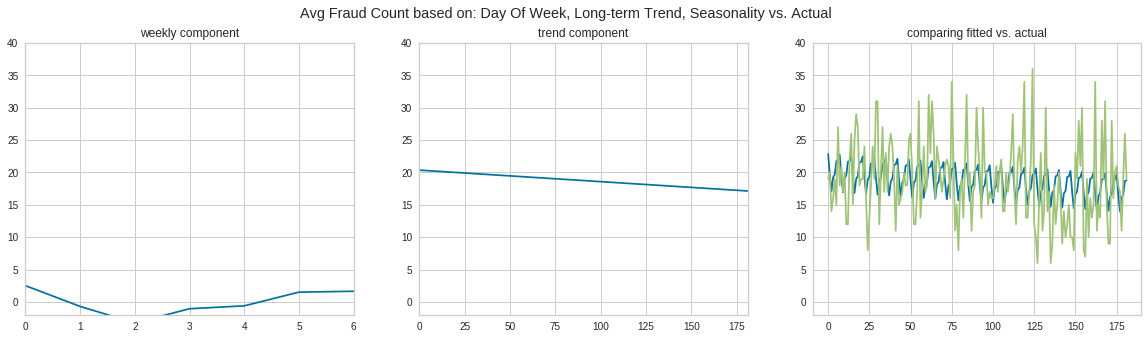

In [46]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
forecast.weekly[:7].plot(ax=ax[0],ylim=(-2,40))
ax[0].set_title("weekly component")
forecast.trend.plot(ax=ax[1],ylim=(-2,40))
ax[1].set_title("trend component")
# ax[1].xticks(forecast.ds)
ax[2].plot(forecast.yhat)
ax[2].plot(df.y)
ax[2].set_ylim(-2,40)
ax[2].set_title("comparing fitted vs. actual")
plt.suptitle('Avg Fraud Count based on: Day Of Week, Long-term Trend, Seasonality vs. Actual')

Text(0.5, 0.98, 'Avg Fraud Rate based on: Day Of Week, Long-term Trend, Seasonality vs. Actual')

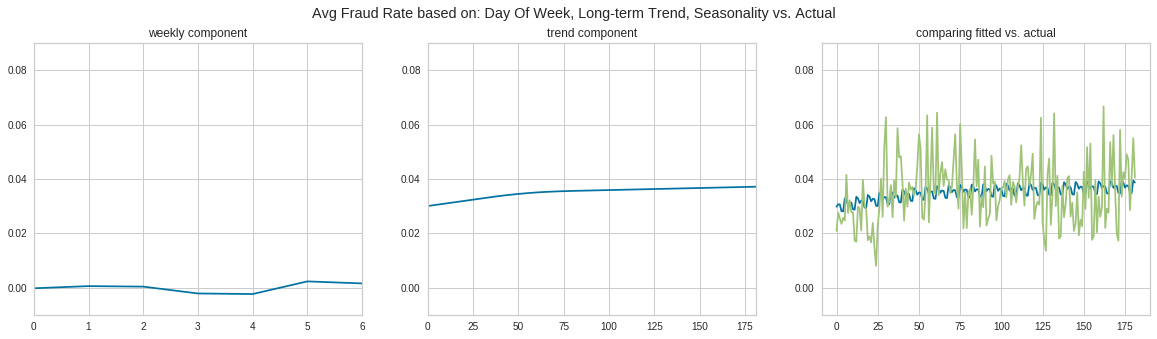

In [47]:
df = train_trx_date[['TransactionDate_','isFraud_mean']]
df.columns = ['ds','y']
prophet = Prophet()
prophet.fit(df)
forecast = prophet.predict(df)

fig,ax = plt.subplots(1,3,figsize=(20,5))
forecast.weekly[:7].plot(ax=ax[0],ylim=(-0.01,0.09))
ax[0].set_title("weekly component")
forecast.trend.plot(ax=ax[1],ylim=(-0.01,0.09))
ax[1].set_title("trend component")
ax[2].plot(forecast.yhat)
ax[2].plot(df.y)
ax[2].set_ylim(-0.01,0.09)
ax[2].set_title("comparing fitted vs. actual")
plt.suptitle('Avg Fraud Rate based on: Day Of Week, Long-term Trend, Seasonality vs. Actual')

## Fraud Rate have relative small weekday seasonality, compared to overall variability

# This is still very early. To be continued!